In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




orders = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_orders_dataset.csv")
order_items = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_order_items_dataset.csv")
customers = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_customers_dataset.csv")
products = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_products_dataset.csv")
payments = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_order_payments_dataset.csv")

In [2]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [5]:
orders.index

RangeIndex(start=0, stop=99441, step=1)

In [6]:
orders['order_id'].nunique()

99441

In [8]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], dayfirst=True)
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], dayfirst=True)
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], dayfirst=True)
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], dayfirst=True)
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], dayfirst=True)

In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [10]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [13]:
orders['order_status'] == 'delivered'

0        True
1        True
2        True
3        True
4        True
         ... 
99436    True
99437    True
99438    True
99439    True
99440    True
Name: order_status, Length: 99441, dtype: bool

In [14]:
delivered_orders = orders[orders['order_status'] == 'delivered']

In [15]:
delivered_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_status                   96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_approved_at              96464 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96476 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [17]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

In [18]:
delivered_orders = delivered_orders.dropna(subset=['order_delivered_customer_date'])

In [19]:
delivered_orders['delivery_time'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_purchase_timestamp']
).dt.days

In [20]:
delivered_orders['delivery_time'].describe()

count    96470.000000
mean        12.094029
std          9.551435
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64

In [21]:
Q1 = delivered_orders['delivery_time'].quantile(0.25)
Q3 = delivered_orders['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_orders = delivered_orders[
    (delivered_orders['delivery_time'] >= lower_bound) &
    (delivered_orders['delivery_time'] <= upper_bound)
]

In [22]:
filtered_orders['delivery_time'].describe()

count    91447.000000
mean        10.558684
std          6.060215
min          0.000000
25%          6.000000
50%          9.000000
75%         14.000000
max         28.000000
Name: delivery_time, dtype: float64

In [24]:
filtered_orders = filtered_orders.copy()

In [25]:
filtered_orders['order_month'] = filtered_orders['order_purchase_timestamp'].dt.to_period('M')

In [26]:
filtered_orders.loc[:, 'order_month'] = filtered_orders['order_purchase_timestamp'].dt.to_period('M')

In [27]:
monthly_delivery = filtered_orders.groupby('order_month')['delivery_time'].mean().reset_index()

In [28]:
monthly_delivery.head()

,order_month,delivery_time
0,2016-10,14.601852
1,2016-12,4.000000
2,2017-01,10.484722
3,2017-02,11.101330
4,2017-03,10.429040


In [29]:
monthly_delivery.tail()

,order_month,delivery_time
17,2018-04,9.869099
18,2018-05,10.114719
19,2018-06,8.247124
20,2018-07,8.111587
21,2018-08,7.220328


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [4]:
orders = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_orders_dataset.csv")
order_items = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_order_items_dataset.csv")
customers = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_customers_dataset.csv")
products = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_products_dataset.csv")
payments = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_order_payments_dataset.csv")

In [5]:
orders_revenue = pd.merge(
    filtered_orders,
    order_revenue,
    on='order_id',
    how='inner'
)

NameError: name 'filtered_orders' is not defined

In [6]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], dayfirst=True)
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], dayfirst=True)

In [7]:
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()

In [8]:
delivered_orders = delivered_orders.dropna(subset=['order_delivered_customer_date'])

In [9]:
delivered_orders['delivery_time'] = (
    delivered_orders['order_delivered_customer_date'] - 
    delivered_orders['order_purchase_timestamp']
).dt.days

In [10]:
Q1 = delivered_orders['delivery_time'].quantile(0.25)
Q3 = delivered_orders['delivery_time'].quantile(0.75)
IQR = Q3 - Q1

filtered_orders = delivered_orders[
    (delivered_orders['delivery_time'] >= Q1 - 1.5 * IQR) &
    (delivered_orders['delivery_time'] <= Q3 + 1.5 * IQR)
].copy()

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt




orders = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_orders_dataset.csv")
order_items = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_order_items_dataset.csv")
customers = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_customers_dataset.csv")
products = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_products_dataset.csv")
payments = pd.read_csv("C:/Users/devarun bharadwaj/Downloads/Data Analytics/Projects/Ecommerce/olist_order_payments_dataset.csv")

In [16]:
order_revenue = order_items.groupby('order_id')['price'].sum().reset_index()

In [17]:
orders_revenue = pd.merge(
    filtered_orders,
    order_revenue,
    on='order_id',
    how='inner'
)

In [18]:
orders_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,2017-10-10 21:25:00,18-10-2017 00:00,8,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,26-07-2018 03:24,26-07-2018 14:31,2018-08-07 15:27:00,13-08-2018 00:00,13,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,08-08-2018 08:55,08-08-2018 13:50,2018-08-17 18:06:00,04-09-2018 00:00,9,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,18-11-2017 19:45,22-11-2017 13:39,2017-12-02 00:28:00,15-12-2017 00:00,13,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,13-02-2018 22:20,14-02-2018 19:46,2018-02-16 18:17:00,26-02-2018 00:00,2,19.90


In [19]:
orders_revenue['order_month'] = orders_revenue['order_purchase_timestamp'].dt.to_period('M')

In [20]:
monthly_revenue = orders_revenue.groupby('order_month')['price'].sum().reset_index()

In [21]:
monthly_revenue.head()

,order_month,price
0,2016-10,30913.72
1,2016-12,10.90
2,2017-01,107173.88
3,2017-02,222304.86
4,2017-03,342106.92


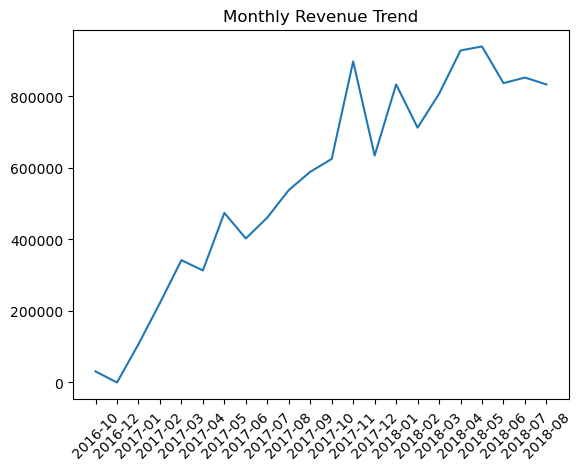

In [22]:
plt.figure()
plt.plot(monthly_revenue['order_month'].astype(str), monthly_revenue['price'])
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.show()

In [23]:
customer_revenue = orders_revenue.groupby('customer_id')['price'].sum().reset_index()

In [24]:
customer_revenue = customer_revenue.sort_values(by='price', ascending=False)

In [25]:
customer_revenue.head()

,customer_id,price
7896,1617b1357756262bfa56ab541c47bc16,13440.0
84614,ec5b2ba62e574342386871631fafd3fc,7160.0
71284,c6e2731c5b391845f6800c97401a43a9,6735.0
87475,f48d464a0baaea338cb25f816991ab1f,6729.0
22816,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0


In [26]:
customer_revenue['rank'] = customer_revenue['price'].rank(method='first', ascending=False)

In [27]:
customer_revenue['rank'] = customer_revenue['price'].rank(method='first', ascending=False)

In [29]:
total_customers = len(customer_revenue)

In [30]:
top_10_percent = int(0.1 * total_customers)

In [31]:
top_customers = customer_revenue.head(top_10_percent)

In [32]:
top_revenue = top_customers['price'].sum()
total_revenue = customer_revenue['price'].sum()

percentage = (top_revenue / total_revenue) * 100
percentage

40.86962288422764

In [33]:
top_customers = customer_revenue[customer_revenue['rank'] <= top_10_percent]

In [34]:
orders_revenue.to_csv("orders_revenue.csv", index=False)

In [35]:
import os
os.getcwd()

'C:\\Users\\devarun bharadwaj'

In [36]:
orders_revenue.to_csv("C:/Users/devarun bharadwaj/Downloads/orders_revenue.csv", index=False)

In [37]:
orders_revenue['order_approved_at'] = pd.to_datetime(orders_revenue['order_approved_at'], dayfirst=True)
orders_revenue['order_delivered_carrier_date'] = pd.to_datetime(orders_revenue['order_delivered_carrier_date'], dayfirst=True)
orders_revenue['order_estimated_delivery_date'] = pd.to_datetime(orders_revenue['order_estimated_delivery_date'], dayfirst=True)

In [38]:
orders_revenue.to_csv("C:/Users/devarun bharadwaj/Downloads/orders_revenue_clean.csv", index=False)

In [39]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_revenue[col] = pd.to_datetime(orders_revenue[col], errors='coerce')

In [40]:
orders_revenue.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      0
order_delivered_customer_date     0
order_estimated_delivery_date     0
delivery_time                     0
price                             0
order_month                       0
dtype: int64

In [41]:
orders_revenue.to_csv(
    "C:/Users/devarun bharadwaj/Downloads/orders_revenue_final.csv",
    index=False
)